In [2]:
import numpy as np
import libpysal
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

Main source: https://github.com/Nithouson/regreg/

In [3]:
def generate_arbitrary_zones(gdf, w, zones=5, min_size=5):
    """
    Grows connected zones round-robin from random seed.
    """
    n = len(gdf)
    if n < zones:
        raise ValueError("The GeoDataFrame has fewer rows than the requested number of zones.")

    units = np.arange(n)

    while True:
        # Pick random distinct polygon row indices as seeds
        seeds = np.random.choice(units, size=zones, replace=False)
        labels = np.full(n, -1, dtype=int)

        for r_id, seed in enumerate(seeds):
            labels[seed] = r_id

        to_assign = set(units[labels == -1])

        # Regional Expansion Phase
        while len(to_assign) > 0:
            progress = False
            for r_id in range(zones):
                region_nodes = units[labels == r_id]

                neighbors = set()
                for node in region_nodes:
                    neighbors.update(w.neighbors[node])
                valid_neighbors = list(neighbors.intersection(to_assign))

                if valid_neighbors:
                    chosen = np.random.choice(valid_neighbors)
                    labels[chosen] = r_id
                    to_assign.remove(chosen)
                    progress = True

            if not progress and len(to_assign) > 0:
                break

        # Validation Phase
        if len(to_assign) == 0:
            counts = [np.sum(labels == r) for r in range(zones)]
            if min(counts) >= min_size:
                break

    return labels

In [4]:
def synthetic_regression_data(gdf, zone_column='zone_id', sigma=0.1):
    """
    Generates synthetic variables (X1, X2, Y) and structural 
    parameters.
    """
    n = len(gdf)
    unique_zones = gdf[zone_column].unique()
    num_zones = len(unique_zones)
    
    # Generate Independent Variables directly into the original object
    gdf['X1'] = np.random.uniform(0, 1, size=n)
    gdf['X2'] = np.random.uniform(0, 1, size=n)
    
    # Map distinct coefficient values across the generated regions
    beta_pool = [-2, -1, 0, 1, 2]
    if num_zones <= len(beta_pool):
        beta1_values = np.random.permutation(beta_pool)[:num_zones]
        beta2_values = np.random.permutation(beta_pool)[:num_zones]
    else:
        beta1_values = np.random.choice(beta_pool, size=num_zones, replace=True)
        beta2_values = np.random.choice(beta_pool, size=num_zones, replace=True)
        
    beta1_map = dict(zip(unique_zones, beta1_values))
    beta2_map = dict(zip(unique_zones, beta2_values))
    
    gdf['beta0'] = 0.0
    gdf['beta1'] = gdf[zone_column].map(beta1_map)
    gdf['beta2'] = gdf[zone_column].map(beta2_map)
    
    # Generate Error Term
    epsilon = np.random.normal(0, sigma, size=n)
    
    # Compute Dependent Variable directly into the original object
    variables = gdf['beta0'] + (gdf['beta1'] * gdf['X1']) + (gdf['beta2'] * gdf['X2']) + epsilon
    return variables

In [5]:
sizes = [100,400]
shapes = ["hex","pent","square"]

In [6]:
min_cluster_sizes = {100:12,400:48}

In [7]:
for size in sizes:
    min_cluster_size = min_cluster_sizes[size]
    for shape in shapes:
        g_true = libpysal.graph.read_parquet(f"graphs/{shape}/size_{size}/g_true.parquet")
        w = g_true.to_W()  
        gdf = gpd.read_parquet(f"data/regionalization/gdf_{shape}_{size}.parquet",columns = ["geometry"])
        for j in range (10):
            zones = generate_arbitrary_zones(gdf,w,min_size = min_cluster_size)
            gdf[f"zone_id_{j}"] = zones
            for i in range (5):
                data = synthetic_regression_data(gdf,zone_column = f'zone_id_{j}')
                gdf[f"zone_run{j}_run{i}"] = data
        gdf.to_parquet(f"data/regionalization/gdf_{shape}_{size}.parquet") 

<Axes: >

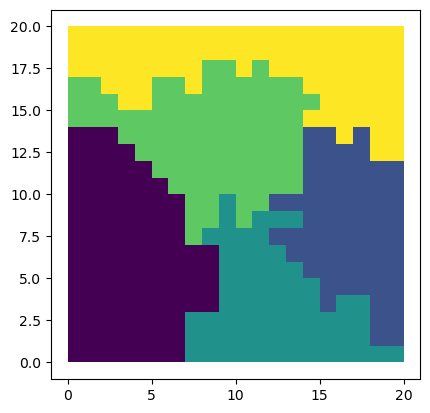

In [8]:
gdf = gpd.read_parquet("data/regionalization/gdf_square_400.parquet")
gdf.plot(column="zone_id_5")

<Axes: >

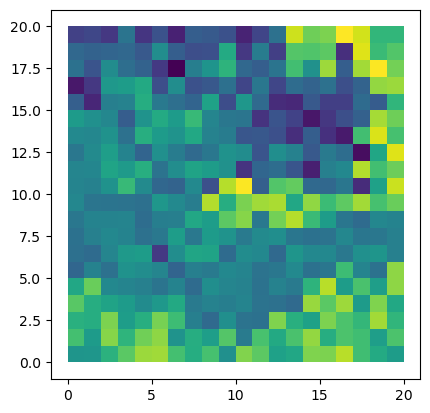

In [9]:
gdf.plot(column=f"zone_run{0}_run{2}")